In [1]:
import numpy as np
from scipy.interpolate import interp1d
from astropy.table import Table
from matplotlib import pyplot as plt
%matplotlib inline

In [2]:
tmp = np.loadtxt("/home/bocquet/SPT_cluster_data/MCMF_lambda_min.txt", unpack=True)
surveyCutLambda = {'shallow': interp1d(tmp[0], tmp[1], kind='linear'),
                   'deep': interp1d(tmp[0], tmp[2], kind='linear')}

In [3]:
cat = Table.read('mock_210713-200836.fits')
cat.colnames, len(cat)

(['SPT_ID',
  'FIELD',
  'XI',
  'THETA_CORE',
  'REDSHIFT',
  'REDSHIFT_UNC',
  'REDSHIFT_LIMIT',
  'Mg_MM',
  'lnMg_err_MM',
  'lnYx_err_MM',
  'M_true',
  'Tx_MM',
  'M500',
  'Mwl_200',
  'richness'],
 1145)

In [4]:
idx = (cat['XI']>5).nonzero()[0]
cat_xigtr5 = cat[idx]
cat_xigtr5.write('mock_xigtr5.fits', overwrite=True)
len(cat_xigtr5)

779

In [5]:
idx = []
for l,lam in enumerate(cat['richness']):
    z = cat['REDSHIFT'][l]
    if z<=1.78:
        if cat['FIELD'][l]=='SPTPOL_500d':
            lambda_min = surveyCutLambda['deep'](z)
        else:
            lambda_min = surveyCutLambda['shallow'](z)
        if lam>lambda_min:
            idx.append(l)
cat_lambdamin = cat[idx]
cat_lambdamin.write('mock_xigtr4p25.fits', overwrite=True)
len(cat_lambdamin)

1140

Text(0, 0.5, 'richness')

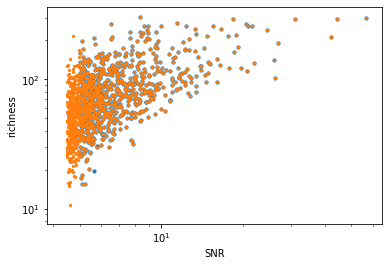

In [6]:
plt.scatter(cat_xigtr5['XI'], cat_xigtr5['richness'], s=10)
plt.scatter(cat_lambdamin['XI'], cat_lambdamin['richness'], s=5)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('SNR')
plt.ylabel('richness')